Étape 1 : Importation des bibliothèques terminée.

Étape 2 : Chargement du dataset réussi.

--- Premières lignes du dataset ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

--- Dimensions du dataset (lignes, colonnes) ---
(768, 9)

--- Noms des variables et types de données ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 

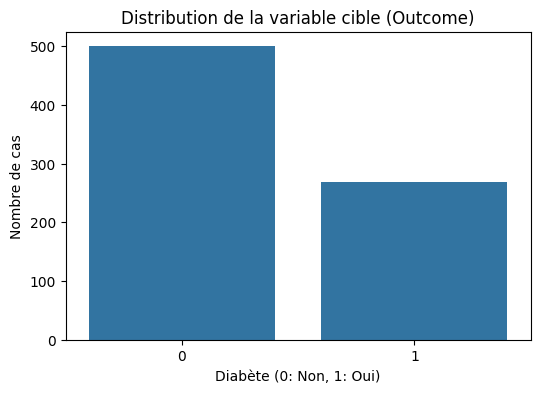


--- Quelques visualisations de caractéristiques ---


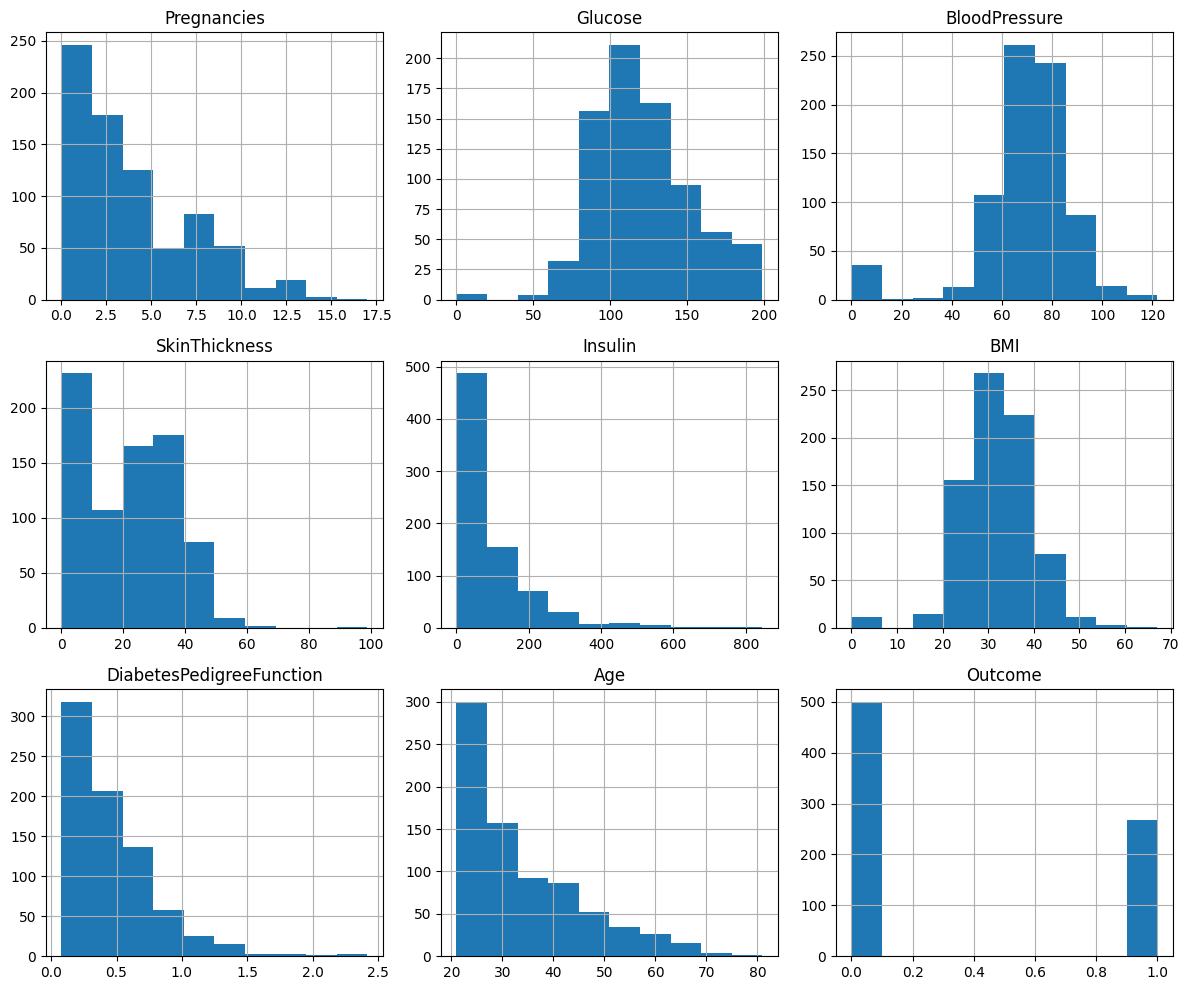


Étape 4 : Préparation des données.
Variables caractéristiques (X) définies. Ex:  ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Variable cible (y) définie. Ex: 'Outcome'

--- Nombre de valeurs NaN après remplacement des 0 ---
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

--- Nombre de valeurs NaN après imputation par la médiane ---
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Caractéristiques normalisées à l'aide de StandardScaler.
Exemple des premières lignes de X_scaled (après normalisation) 

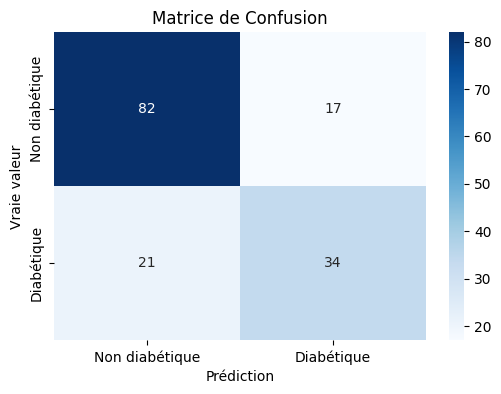


Interprétation : L'accuracy indique la proportion globale de bonnes prédictions.
La matrice de confusion nous montre que le modèle identifie correctement un bon nombre de diabétiques (True Positives),
mais fait aussi des erreurs (Faux Négatifs et Faux Positifs). Le rappel pour la classe 1 (diabétique) est particulièrement important.

Étape 10 : Validation du modèle par Validation Croisée (K-Fold).

Scores d'accuracy obtenus par validation croisée (5 folds) :
[0.75974026 0.74675325 0.78571429 0.79738562 0.77124183]
Accuracy moyenne de la validation croisée : 0.7722
Écart-type des scores de la validation croisée : 0.0180

Interprétation : Une faible variabilité (écart-type) entre les scores indique que le modèle est stable
et ne dépend pas trop d'une répartition particulière des données. L'accuracy moyenne donne une estimation plus fiable de la performance générale.

Étape 11 : Prédiction sur une nouvelle observation.

--- Nouvelle observation à prédire ---
   Pregnancies  Glucose  Bloo

/tmp/ipykernel_1891/2079038141.py:354: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nouvelle_donnee[col].fillna(medians_for_imputation[col], inplace=True)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Objectif du script ---
"""
Ce script Python est conçu comme un exemple pédagogique complet pour un projet de Machine Learning supervisé
dans Google Colab. Il couvre les étapes essentielles, du chargement des données à l'utilisation d'un modèle
entraîné sur une nouvelle observation.

Le jeu de données utilisé est le Pima Indians Diabetes Dataset, une base de données simple et publique
permettant de prédire si une personne est diabétique ou non, basée sur diverses mesures de santé.

Chaque étape est expliquée en détail avec des commentaires pour faciliter la compréhension des étudiants.
"""

# =============================================================================
# Étape 1 — Importation des bibliothèques
# =============================================================================
"""
Nous commençons par importer toutes les bibliothèques Python nécessaires pour ce projet.
Chacune a un rôle spécifique :
-   **pandas** : Pour la manipulation et l'analyse des données (DataFrames).
-   **numpy** : Pour les opérations numériques, notamment avec les tableaux.
-   **matplotlib.pyplot** et **seaborn** : Pour la visualisation des données.
-   **sklearn.model_selection.train_test_split** : Pour diviser les données en ensembles d'entraînement et de test.
-   **sklearn.model_selection.cross_val_score** : Pour l'évaluation du modèle par validation croisée.
-   **sklearn.preprocessing.StandardScaler** : Pour la normalisation des caractéristiques.
-   **sklearn.linear_model.LogisticRegression** : L'algorithme de classification que nous utiliserons.
-   **sklearn.metrics** : Pour évaluer la performance de notre modèle (accuracy, rapport de classification, matrice de confusion).
"""
print("Étape 1 : Importation des bibliothèques terminée.")

# =============================================================================
# Étape 2 — Chargement du dataset
# =============================================================================
"""
Nous allons charger le jeu de données Pima Indians Diabetes directement depuis une URL publique.
Ce dataset contient des informations médicales et une variable cible ('Outcome') indiquant la présence de diabète.

Après le chargement, nous afficherons les premières lignes, les dimensions, les noms des variables
et leurs types de données pour avoir un premier aperçu.
"""

# URL du dataset Pima Indians Diabetes
dataset_url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

try:
    df = pd.read_csv(dataset_url)
    print("\nÉtape 2 : Chargement du dataset réussi.")

    print("\n--- Premières lignes du dataset ---")
    print(df.head())

    print("\n--- Dimensions du dataset (lignes, colonnes) ---")
    print(df.shape)

    print("\n--- Noms des variables et types de données ---")
    print(df.info())

    print("\n--- Statistiques descriptives initiales ---")
    print(df.describe().T)

except Exception as e:
    print(f"Erreur lors du chargement du dataset : {e}")
    print("Veuillez vérifier l'URL ou votre connexion internet.")
    exit()

# =============================================================================
# Étape 3 — Exploration des données (EDA)
# =============================================================================
"""
L'exploration des données (Exploratory Data Analysis - EDA) nous aide à comprendre les caractéristiques
du dataset, à identifier les problèmes potentiels (comme les valeurs manquantes ou aberrantes)
et à formuler des hypothèses.

Dans ce dataset, il est connu que des valeurs de 0 dans certaines colonnes (comme Glucose, BloodPressure,
SkinThickness, Insulin, BMI) sont biologiquement impossibles et représentent en réalité des valeurs manquantes.
Nous allons d'abord les identifier.
"""
print("\nÉtape 3 : Exploration des données.")

print("\n--- Vérification des valeurs manquantes (valeurs 0 représentant des NaN) ---")
# Les colonnes où 0 est une valeur manquante
columns_with_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_zero_as_missing:
    # Compte le nombre de 0 dans chaque colonne problématique
    print(f"Nombre de 0 dans '{col}': {(df[col] == 0).sum()}")

print("\n--- Distribution de la variable cible ('Outcome') ---")
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df)
plt.title('Distribution de la variable cible (Outcome)')
plt.xlabel('Diabète (0: Non, 1: Oui)')
plt.ylabel('Nombre de cas')
plt.show()

print("\n--- Quelques visualisations de caractéristiques ---")
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

# =============================================================================
# Étape 4 — Préparation des données
# =============================================================================
"""
La préparation des données est cruciale pour le bon fonctionnement des algorithmes de Machine Learning.
Elle implique la définition des caractéristiques (X) et de la cible (y), ainsi que le traitement
des valeurs manquantes et la normalisation des données.

1.  **Définition de X et y** : X représente les caractéristiques d'entrée, et y la variable que nous voulons prédire.
2.  **Traitement des valeurs manquantes** : Nous remplaçons les 0 identifiés précédemment par `NaN` (Not a Number),
    puis nous imputons ces `NaN` avec la médiane de chaque colonne respective. La médiane est moins sensible
    aux valeurs extrêmes que la moyenne.
3.  **Normalisation des données** : Les algorithmes basés sur les distances (comme la régression logistique)
    sont sensibles à l'échelle des caractéristiques. `StandardScaler` transforme les données de manière
    à ce qu'elles aient une moyenne de 0 et un écart-type de 1. C'est une étape importante pour éviter
    qu'une caractéristique avec de grandes valeurs n'ait un poids disproportionné.
"""
print("\nÉtape 4 : Préparation des données.")

# Définition des caractéristiques (X) et de la cible (y)
X = df.drop('Outcome', axis=1) # Toutes les colonnes sauf 'Outcome'
y = df['Outcome']              # La colonne 'Outcome' est notre cible

print("Variables caractéristiques (X) définies. Ex: ", X.columns.tolist())
print("Variable cible (y) définie. Ex: 'Outcome'")

# Remplacer les 0 par NaN dans les colonnes pertinentes
X_prepared = X.copy() # Travailler sur une copie pour ne pas modifier le DataFrame original
for col in columns_with_zero_as_missing:
    X_prepared[col] = X_prepared[col].replace(0, np.nan)

print("\n--- Nombre de valeurs NaN après remplacement des 0 ---")
print(X_prepared.isnull().sum())

# Imputation des valeurs manquantes avec la médiane
# Nous utilisons X_prepared.median() pour calculer les médianes et fillna pour les remplacer
X_prepared.fillna(X_prepared.median(), inplace=True)

print("\n--- Nombre de valeurs NaN après imputation par la médiane ---")
print(X_prepared.isnull().sum())

# Normalisation des caractéristiques
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prepared) # fit_transform calcule la moyenne/écart-type et applique la transformation

print("\nCaractéristiques normalisées à l'aide de StandardScaler.")
print("Exemple des premières lignes de X_scaled (après normalisation) :")
print(X_scaled[:5])

# =============================================================================
# Étape 5 — Séparation entraînement/test
# =============================================================================
"""
Pour évaluer la performance de notre modèle de manière objective, nous divisons nos données en deux ensembles :

-   **Ensemble d'entraînement (X_train, y_train)** : Utilisé pour 'apprendre' au modèle les motifs des données.
-   **Ensemble de test (X_test, y_test)** : Utilisé pour évaluer la capacité du modèle à généraliser sur des données
    qu'il n'a jamais vues. Il est crucial que le modèle ne voie jamais ces données pendant l'entraînement.

Nous utilisons 80% des données pour l'entraînement et 20% pour le test (`test_size=0.2`).
`random_state=42` assure que la division est la même à chaque exécution du script, garantissant la reproductibilité.
"""
print("\nÉtape 5 : Séparation des données en ensembles d'entraînement et de test.")

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement : {X_train.shape[0]} échantillons.")
print(f"Taille de l'ensemble de test : {X_test.shape[0]} échantillons.")

# =============================================================================
# Étape 6 — Création du modèle
# =============================================================================
"""
Nous choisissons ici un modèle de **Régression Logistique**.

**Pourquoi la Régression Logistique ?**
-   C'est un algorithme de classification binaire simple, puissant et largement utilisé.
-   Il est bien adapté à notre problème où la variable cible ('Outcome') est binaire (0 ou 1).
-   Il fournit des probabilités de classe, ce qui peut être utile pour l'interprétation.
-   Il est relativement rapide à entraîner et facile à comprendre.

Nous initialisons le modèle avec `random_state=42` pour garantir la reproductibilité des résultats
lors de l'entraînement, notamment si l'algorithme utilise des aspects stochastiques.
"""
print("\nÉtape 6 : Création du modèle de Régression Logistique.")

model = LogisticRegression(random_state=42)
print("Modèle de Régression Logistique créé.")

# =============================================================================
# Étape 7 — Entraînement du modèle
# =============================================================================
"""
L'étape d'entraînement consiste à "apprendre" au modèle à faire des prédictions en utilisant
les données d'entraînement (X_train et y_train).
Le modèle ajuste ses paramètres internes pour minimiser l'erreur de prédiction sur ces données.
"""
print("\nÉtape 7 : Entraînement du modèle.")

model.fit(X_train, y_train)
print("Modèle entraîné avec succès sur les données d'entraînement.")

# =============================================================================
# Étape 8 — Prédictions sur l'ensemble de test
# =============================================================================
"""
Une fois le modèle entraîné, nous l'utilisons pour faire des prédictions sur l'ensemble de test (X_test).
Ces prédictions (y_pred) seront ensuite comparées aux vraies valeurs (y_test) pour évaluer la performance du modèle.
"""
print("\nÉtape 8 : Réalisation des prédictions sur l'ensemble de test.")

y_pred = model.predict(X_test)

print("\n--- Comparaison de quelques valeurs réelles et prédites ---")
results = pd.DataFrame({'Valeur Réelle': y_test, 'Valeur Prédite': y_pred})
print(results.head(10))

# =============================================================================
# Étape 9 — Évaluation du modèle
# =============================================================================
"""
L'évaluation est essentielle pour comprendre la performance de notre modèle. Pour un problème de classification,
les métriques courantes incluent :

-   **Accuracy (Précision)** : La proportion d'échantillons correctement classés.
-   **Classification Report** : Fournit la précision (precision), le rappel (recall), le score F1 et le support
    pour chaque classe. Le rappel est important pour notre problème (ne pas rater un diabétique).
-   **Matrice de Confusion** : Un tableau qui montre le nombre de vrais positifs, vrais négatifs, faux positifs
    et faux négatifs. Elle permet de visualiser où le modèle se trompe.
"""
print("\nÉtape 9 : Évaluation du modèle.")

# Calcul de l'accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy du modèle sur l'ensemble de test : {accuracy:.4f}")

# Rapport de classification
print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))

# Matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
print("\n--- Matrice de Confusion ---")
print(conf_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non diabétique', 'Diabétique'],
            yticklabels=['Non diabétique', 'Diabétique'])
plt.xlabel('Prédiction')
plt.ylabel('Vraie valeur')
plt.title('Matrice de Confusion')
plt.show()

print("\nInterprétation : L'accuracy indique la proportion globale de bonnes prédictions.")
print("La matrice de confusion nous montre que le modèle identifie correctement un bon nombre de diabétiques (True Positives),")
print("mais fait aussi des erreurs (Faux Négatifs et Faux Positifs). Le rappel pour la classe 1 (diabétique) est particulièrement important.")

# =============================================================================
# Étape 10 — Validation du modèle (Validation Croisée)
# =============================================================================
"""
La validation croisée est une technique plus robuste pour évaluer la performance d'un modèle
que le simple split entraînement/test. Elle aide à estimer la **stabilité** et la **capacité de généralisation**
du modèle en réduisant la dépendance à une seule division des données.

Le principe du k-fold cross-validation est de :
1.  Diviser l'ensemble d'entraînement en `k` sous-ensembles (folds).
2.  Entraîner le modèle `k` fois, à chaque fois sur `k-1` folds et valider sur le fold restant.
3.  Calculer la moyenne et l'écart-type des scores obtenus sur les `k` itérations.

Nous utilisons ici `cv=5`, ce qui signifie 5 folds (5-fold cross-validation).
"""
print("\nÉtape 10 : Validation du modèle par Validation Croisée (K-Fold).")

# Effectuer la validation croisée sur les données d'entraînement (X_scaled, y)
# Le modèle est entraîné et évalué sur différentes divisions des données.
# random_state=42 est utilisé dans LogisticRegression, pas directement dans cross_val_score.
# Cependant, on peut s'assurer que les splits de CV sont reproductibles avec un 'splitter'
# Par simplicité ici, nous laissons cross_val_score gérer les splits aléatoirement pour chaque exécution.

cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')

print("\nScores d'accuracy obtenus par validation croisée (5 folds) :")
print(cv_scores)
print(f"Accuracy moyenne de la validation croisée : {cv_scores.mean():.4f}")
print(f"Écart-type des scores de la validation croisée : {cv_scores.std():.4f}")

print("\nInterprétation : Une faible variabilité (écart-type) entre les scores indique que le modèle est stable")
print("et ne dépend pas trop d'une répartition particulière des données. L'accuracy moyenne donne une estimation plus fiable de la performance générale.")

# =============================================================================
# Étape 11 — Exemple final avec une nouvelle observation
# =============================================================================
"""
C'est l'étape la plus concrète : utiliser notre modèle entraîné pour prédire sur une observation
complètement nouvelle, qui n'a fait partie ni de l'entraînement, ni du test, ni de la validation croisée.

Il est crucial d'appliquer les **mêmes étapes de prétraitement** (ici, la normalisation via `scaler`)
à la nouvelle donnée qu'à l'ensemble d'entraînement. Le `scaler` doit être celui qui a été `fit`
sur les données d'entraînement (`X_prepared`).
"""
print("\nÉtape 11 : Prédiction sur une nouvelle observation.")

# Création d'une nouvelle observation (exemple fictif)
# Les valeurs doivent correspondre à l'ordre des caractéristiques du dataset original:
# ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
nouvelle_donnee = pd.DataFrame({
    'Pregnancies': [2],
    'Glucose': [130],
    'BloodPressure': [72],
    'SkinThickness': [35],
    'Insulin': [0], # Supposons que 0 signifie manquant ici aussi
    'BMI': [33.6],
    'DiabetesPedigreeFunction': [0.627],
    'Age': [45]
})

print("\n--- Nouvelle observation à prédire ---")
print(nouvelle_donnee)

# Traitement de la nouvelle donnée : remplacement des 0 par NaN et imputation
# On utilise le même processus que pour les données d'entraînement
for col in columns_with_zero_as_missing:
    if col in nouvelle_donnee.columns:
        nouvelle_donnee[col] = nouvelle_donnee[col].replace(0, np.nan)

# Imputation des valeurs manquantes avec les médianes CALCULÉES SUR LES DONNÉES D'ENTRAÎNEMENT
# C'est très important d'utiliser les statistiques (médianes) du jeu d'entraînement original (X_prepared)
# Le scaler contient déjà la logique. Pour l'imputation, on reprend les médianes calculées plus tôt.
# Le StandardScaler s'occupera de la mise à l'échelle. Pour l'imputation, il faut refaire.
# Un pipeline serait idéal mais on reste simple ici.

# Pour cet exemple simple, nous allons réappliquer l'imputation si des NaN sont présents
# ou simplement s'assurer que le 0 initial est géré.
# Le StandardScaler gérera les NaN si on le lui passe, mais il est mieux de les imputer avant.

# Méthode plus robuste: utiliser les médianes de X_prepared
medians_for_imputation = X_prepared.median()
for col in columns_with_zero_as_missing:
    if col in nouvelle_donnee.columns and nouvelle_donnee[col].isnull().any():
        nouvelle_donnee[col].fillna(medians_for_imputation[col], inplace=True)

print("\nNouvelle observation après traitement des valeurs 0/NaN :")
print(nouvelle_donnee)

# Normalisation de la nouvelle observation avec le scaler ENTRAÎNÉ
# C'est crucial d'utiliser le scaler qui a été `fit` sur les données d'entraînement pour éviter le data leakage.
# .transform() est utilisé ici, PAS .fit_transform().
new_data_scaled = scaler.transform(nouvelle_donnee)

print("\nNouvelle observation après normalisation :")
print(new_data_scaled)

# Prédiction
prediction = model.predict(new_data_scaled)
prediction_proba = model.predict_proba(new_data_scaled)

print("\n--- Résultat de la prédiction ---")
if prediction[0] == 1:
    print("Le modèle prédit que la personne EST diabétique.")
else:
    print("Le modèle prédit que la personne N'EST PAS diabétique.")

print(f"Probabilité d'être non-diabétique (classe 0) : {prediction_proba[0][0]:.4f}")
print(f"Probabilité d'être diabétique (classe 1) : {prediction_proba[0][1]:.4f}")

print("\nInterprétation : Le modèle estime, en se basant sur les caractéristiques fournies,")
print("la probabilité que cette nouvelle personne soit diabétique. Si la probabilité pour la classe 1")
print("dépasse un certain seuil (souvent 0.5 par défaut pour la régression logistique), la classe 1 est prédite.")

print("\n--- Fin du script pédagogique --- ")
